In [1]:
# Import des données traitées
from numpy import select
import pandas as pd
import duckdb
pd.set_option('display.max_columns', None)

chemin_fichier_order = r"F_orders.parquet"
chemin_fichier_product = r"D_products.parquet"
chemin_fichier_canal = r"d_facture_clean.parquet"
chemin_fichier_client = r"dim_client.parquet"

df_ML_customer=duckdb.query(f"""
    with order_complete as(
        SELECT
            o.*,
            CASE
                WHEN o.TotalDiscountGBP=0 THEN 0
                ELSE 1
            END AS check_promotion,

            --CASE
            --    WHEN o.PromotionCode_clean='NONE' THEN 1
            --    ELSE 0
            --END AS check_promotion_none,
            --CASE
            --    WHEN o.PromotionCode_clean='CLEARANCE' THEN 1
            --    ELSE 0
            --END AS check_promotion_clearance,
            --CASE
            --    WHEN o.PromotionCode_clean='SPRING' THEN 1
            --    ELSE 0
            --END AS check_promotion_spring,
            --CASE
            --    WHEN o.PromotionCode_clean='WELCOME10' THEN 1
            --   ELSE 0
            --END AS check_promotion_welcome,
            --CASE
            --    WHEN o.PromotionCode_clean='XMAS' THEN 1
            --    ELSE 0
            --END AS check_promotion_xmas,
            --CASE
            --    WHEN o.PromotionCode_clean='VIP' THEN 1
            --    ELSE 0
            --END AS check_promotion_vip,

            p.ProductCategory_Propre,
            c.SalesChannel,
            cl.CustomerSegment,
        From read_parquet('{chemin_fichier_order}') as o
        LEFT JOIN read_parquet('{chemin_fichier_product}') as p
            ON p.StockCode = o.StockCode
        LEFT JOIN read_parquet('{chemin_fichier_canal}') as c
            ON c.Invoice=o.Invoice
        LEFT JOIN read_parquet('{chemin_fichier_client}') as cl
            ON cl.CustomerID=o.CustomerID_clean
    )                        

    select 
        CustomerID_clean,
        CustomerSegment,
        COUNT(DISTINCT(OrderLineID)) as total_lignes_commandes,
        SUM(TotalPriceGBP) as total_CA,
        SUM(TotalPriceGBP_WithDiscount) as total_CA_apres_remise,
        SUM(Quantity_clean) as Total_quantite,
        SUM(Quantity_clean)/COUNT(DISTINCT(Invoice)) as quantite_moyenne_par_facture,
        SUM(TotalPriceGBP_WithDiscount)/SUM(Quantity_clean) as panier_moyen,
        SUM(TotalDiscountGBP)/SUM(TotalPriceGBP) as remise_moyenne,
        SUM(check_promotion) as nb_lignecommande_avec_promo,

        --SUM(check_promotion_none) as nb_lignecommande_promo_none,
        --SUM(check_promotion_clearance) as nb_lignecommande_promo_clearance,
        --SUM(check_promotion_spring) as nb_lignecommande_promo_spring,
        --SUM(check_promotion_welcome) as nb_lignecommande_avec_welcome,
        --SUM(check_promotion_xmas) as nb_lignecommande_avec_xmas,
        --SUM(check_promotion_vip) as nb_lignecommande_avec_vip,

        SUM(check_promotion)/COUNT(DISTINCT(OrderLineID))*100 as pourcent_lignescommandes_avec_promo,
        MODE(country_clean) AS pays_prefere,
        MODE(ProductCategory_Propre) AS categorie_preferee,
        MODE(SalesChannel) AS canal_prefere,
        MODE(PromotionCode_clean) AS codePromotion_prefere,
        -- 1. LA RÉCENCE (en jours)
        -- On calcule la différence entre la date d'achat la plus récente (MAX) et notre date de référence
        DATE_DIFF('day', MAX(InvoiceDate_clean), CAST('2012-01-01' AS DATE)) AS recence_jours,
        -- 2. LA FRÉQUENCE SUR 1 AN (Nombre de factures distinctes)
        -- On compte les 'Invoice' uniques, mais UNIQUEMENT si l'achat a eu lieu dans les 365 jours avant la référence
        COUNT(DISTINCT Invoice) FILTER (WHERE DATE_DIFF('day', InvoiceDate_clean, CAST('2012-01-01' AS DATE)) <= 365) AS nb_achats_annee
    From order_complete
    GROUP BY CustomerID_clean, CustomerSegment
""").df()

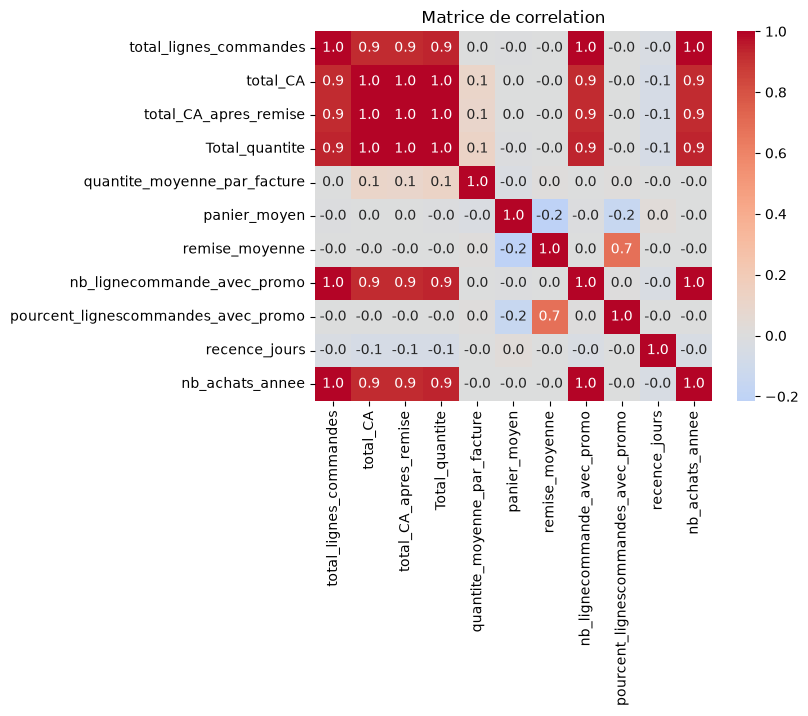

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation=df_ML_customer.select_dtypes(include='number').corr()

sns.heatmap(correlation, annot=True, fmt='.1f', cmap='coolwarm', center=0)
plt.title("Matrice de correlation")
plt.show()

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    confusion_matrix
)
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [11]:
X=df_ML_customer[['total_CA_apres_remise', 'quantite_moyenne_par_facture', 'panier_moyen','remise_moyenne', 'pourcent_lignescommandes_avec_promo','recence_jours','canal_prefere']]
y_segment= df_ML_customer['CustomerSegment']

num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(exclude="number").columns

# Transformations numériques
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Transformations catégoriques
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Préprocess : le ColumnTransformer va dire à quelles colonnes appliquer quel transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

# Créer le pipeline complet avec une régression linéaire
pipeline_DBSCAN = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DBSCAN(eps=1.45,min_samples=3))
])

In [18]:
X_preprocessed = preprocessor.fit_transform(X)

link_matrix = linkage(          # linkage() permet de construire le dendogramme
    X_preprocessed,
    method="ward"
)

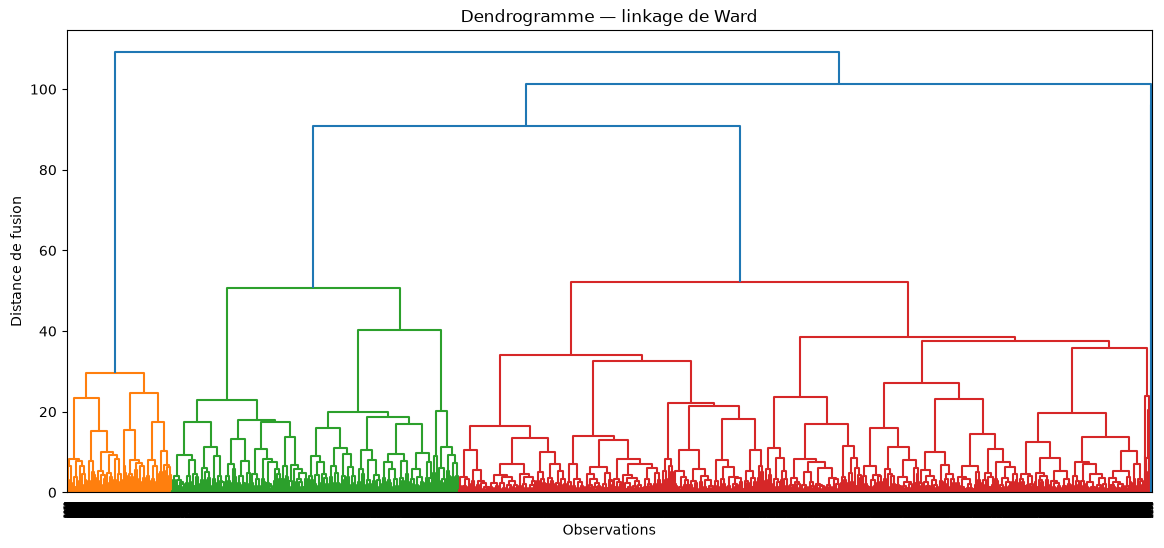

In [20]:
plt.figure(figsize=(14, 6))

dendrogram(
    link_matrix,
)

plt.title("Dendrogramme — linkage de Ward")
plt.xlabel("Observations")
plt.ylabel("Distance de fusion")
plt.show()

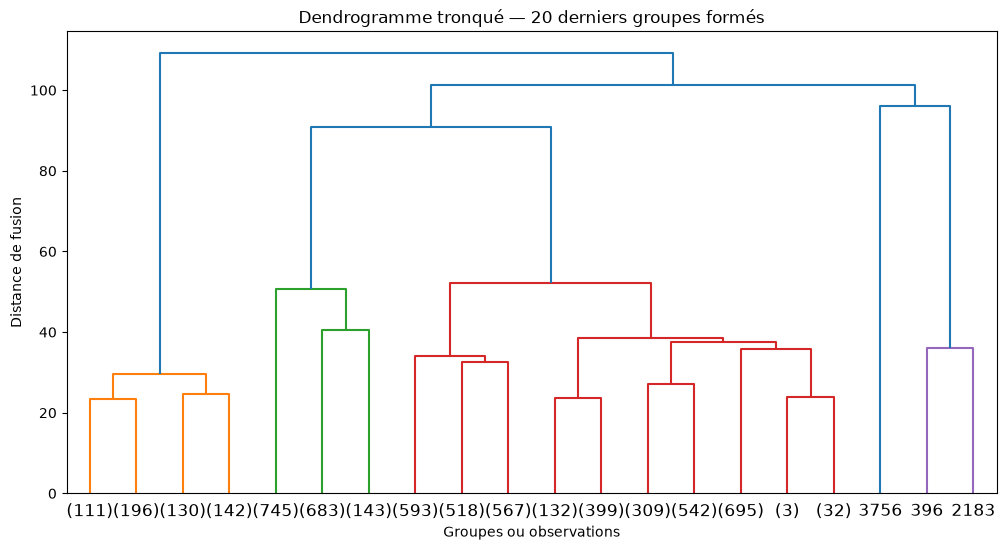

In [19]:
plt.figure(figsize=(12, 6))

dendrogram(
    link_matrix,
    truncate_mode="lastp",          # N'afficher que les p derniers clusters créés.
    p=20
)

plt.title("Dendrogramme tronqué — 20 derniers groupes formés")
plt.xlabel("Groupes ou observations")
plt.ylabel("Distance de fusion")
plt.show()

In [ ]:
hierarchical_k5 = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

clusters_k5 = hierarchical_k5.fit_predict(X_preprocessed)

df_k5 = X.copy()
df_k5["cluster"] = clusters_k5

display(df_k5.sample(5))

,total_CA_apres_remise,quantite_moyenne_par_facture,panier_moyen,remise_moyenne,pourcent_lignescommandes_avec_promo,recence_jours,canal_prefere,cluster
3934,118559.716856,361.000000,11.729295,0.117262,81.395349,25,Store,0
3406,37893.764461,391.111111,10.765274,0.111294,81.087470,30,Online,0
2209,529.631958,24.000000,22.067998,0.100000,100.000000,451,Marketplace,1
615,5990.567440,183.000000,16.367671,0.104966,100.000000,450,Online,1
4143,6722.747558,114.000000,8.424496,0.129332,100.000000,168,Online,0


In [26]:
cluster_sizes = (
    df_k5["cluster"]
    .value_counts()
    .sort_index()
    .rename("nombre_observations")
)

cluster_profiles = (
    df_k5
    .groupby("cluster")
    .mean(numeric_only=True)
    .round(2)
)

display(cluster_sizes)
display(cluster_profiles)

cluster
0    3790
1    1571
2       2
3       1
4     579
Name: nombre_observations, dtype: int64

,total_CA_apres_remise,quantite_moyenne_par_facture,panier_moyen,remise_moyenne,pourcent_lignescommandes_avec_promo,recence_jours
cluster,,,,,,
0,27739.05,213.03,10.78,0.11,84.14,95.96
1,4570.11,155.67,11.11,0.12,95.06,488.77
2,731052.56,63832.75,6.83,0.13,100.00,242.00
3,16519943.88,100.20,9.89,0.09,79.79,23.00
4,4221.27,154.37,12.49,0.01,14.08,359.01


In [29]:
df_k5["CustomerSegment"]=df_ML_customer['CustomerSegment']
df_k5["canal_prefere"]=df_ML_customer['canal_prefere']

In [ ]:
comparison = pd.crosstab(
    df_k5["cluster"],
    df_k5["CustomerSegment"],
    rownames=["cluster"],
    colnames=["Segmentation actuelle"]
)

comparison

Segmentation actuelle,Low value,Loyal,Regular,VIP
cluster,,,,
0,943,949,933,965
1,415,351,420,385
2,0,1,0,1
3,0,0,0,1
4,136,146,155,142


In [ ]:
comparison_2 = pd.crosstab(
    df_k5["cluster"],
    df_k5["canal_prefere"],
    rownames=["cluster"],
    colnames=["canal_prefere actuel"]
)

comparison_2